In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [28]:
df = pd.read_csv("D:\Dataset\CAR DETAILS FROM CAR DEKHO.csv")

In [29]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner


In [30]:
df.shape

(4340, 8)

In [31]:
# Extract the brand name (first word in the 'name' column)
df['brand'] = df['name'].apply(lambda x: x.split()[0])

In [32]:
df.head()

,name,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,Maruti 800 AC,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,Maruti Wagon R LXI Minor,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,Hyundai Verna 1.6 SX,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,Datsun RediGO T Option,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,Honda Amaze VX i-DTEC,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


In [33]:
df.drop(columns=['name'],inplace=True, axis=1)

In [34]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


In [35]:
import numpy as np

# Function to detect outliers using IQR
def detect_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data[column] < lower_bound) | (data[column] > upper_bound)]
    return outliers, lower_bound, upper_bound

# Function to cap outliers
def cap_outliers(data, column):
    _, lower_bound, upper_bound = detect_outliers_iqr(data, column)
    data[column] = np.where(data[column] < lower_bound, lower_bound, data[column])
    data[column] = np.where(data[column] > upper_bound, upper_bound, data[column])
    return data


In [36]:

# Detecting and treating outliers in numerical columns
numerical_columns = ["selling_price", "km_driven"]



In [37]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000,70000,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000,50000,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000,100000,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000,46000,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000,141000,Diesel,Individual,Manual,Second Owner,Honda


In [38]:
for col in numerical_columns:
    outliers, lower, upper = detect_outliers_iqr(df, col)
    print(f"Outliers in {col}: {len(outliers)}")
    car_data = cap_outliers(df, col)

# Verify the changes
print(car_data.describe())

Outliers in selling_price: 271
Outliers in km_driven: 110
              year  selling_price      km_driven
count  4340.000000   4.340000e+03    4340.000000
mean   2013.090783   4.419889e+05   64711.526267
std       4.215344   3.076974e+05   39833.930145
min    1992.000000   2.000000e+04       1.000000
25%    2011.000000   2.087498e+05   35000.000000
50%    2014.000000   3.500000e+05   60000.000000
75%    2016.000000   6.000000e+05   90000.000000
max    2020.000000   1.186875e+06  172500.000000


In [39]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000.0,50000.0,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000.0,100000.0,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000.0,46000.0,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000.0,141000.0,Diesel,Individual,Manual,Second Owner,Honda


In [40]:
numeric_features = [feature for feature in df.columns if df[feature].dtype != 'O']
categorical_feature = [feature for feature in df.columns if df[feature].dtype =='O']


# Print columns
print("We have {} numerical features : {}".format(len(numeric_features),numeric_features))
print('\nWe have {} categorical feature : {}'.format(len(categorical_feature),categorical_feature))

We have 3 numerical features : ['year', 'selling_price', 'km_driven']

We have 5 categorical feature : ['fuel', 'seller_type', 'transmission', 'owner', 'brand']


In [41]:
for col in categorical_feature:
    print(df[col].value_counts(normalize=True)*100)
    print('---------------------')

fuel
Diesel      49.608295
Petrol      48.917051
CNG          0.921659
LPG          0.529954
Electric     0.023041
Name: proportion, dtype: float64
---------------------
seller_type
Individual          74.746544
Dealer              22.903226
Trustmark Dealer     2.350230
Name: proportion, dtype: float64
---------------------
transmission
Manual       89.677419
Automatic    10.322581
Name: proportion, dtype: float64
---------------------
owner
First Owner             65.253456
Second Owner            25.483871
Third Owner              7.004608
Fourth & Above Owner     1.866359
Test Drive Car           0.391705
Name: proportion, dtype: float64
---------------------
brand
Maruti           29.493088
Hyundai          18.917051
Mahindra          8.410138
Tata              8.317972
Honda             5.806452
Ford              5.483871
Toyota            4.746544
Chevrolet         4.331797
Renault           3.364055
Volkswagen        2.465438
Skoda             1.566820
Nissan            1.47465

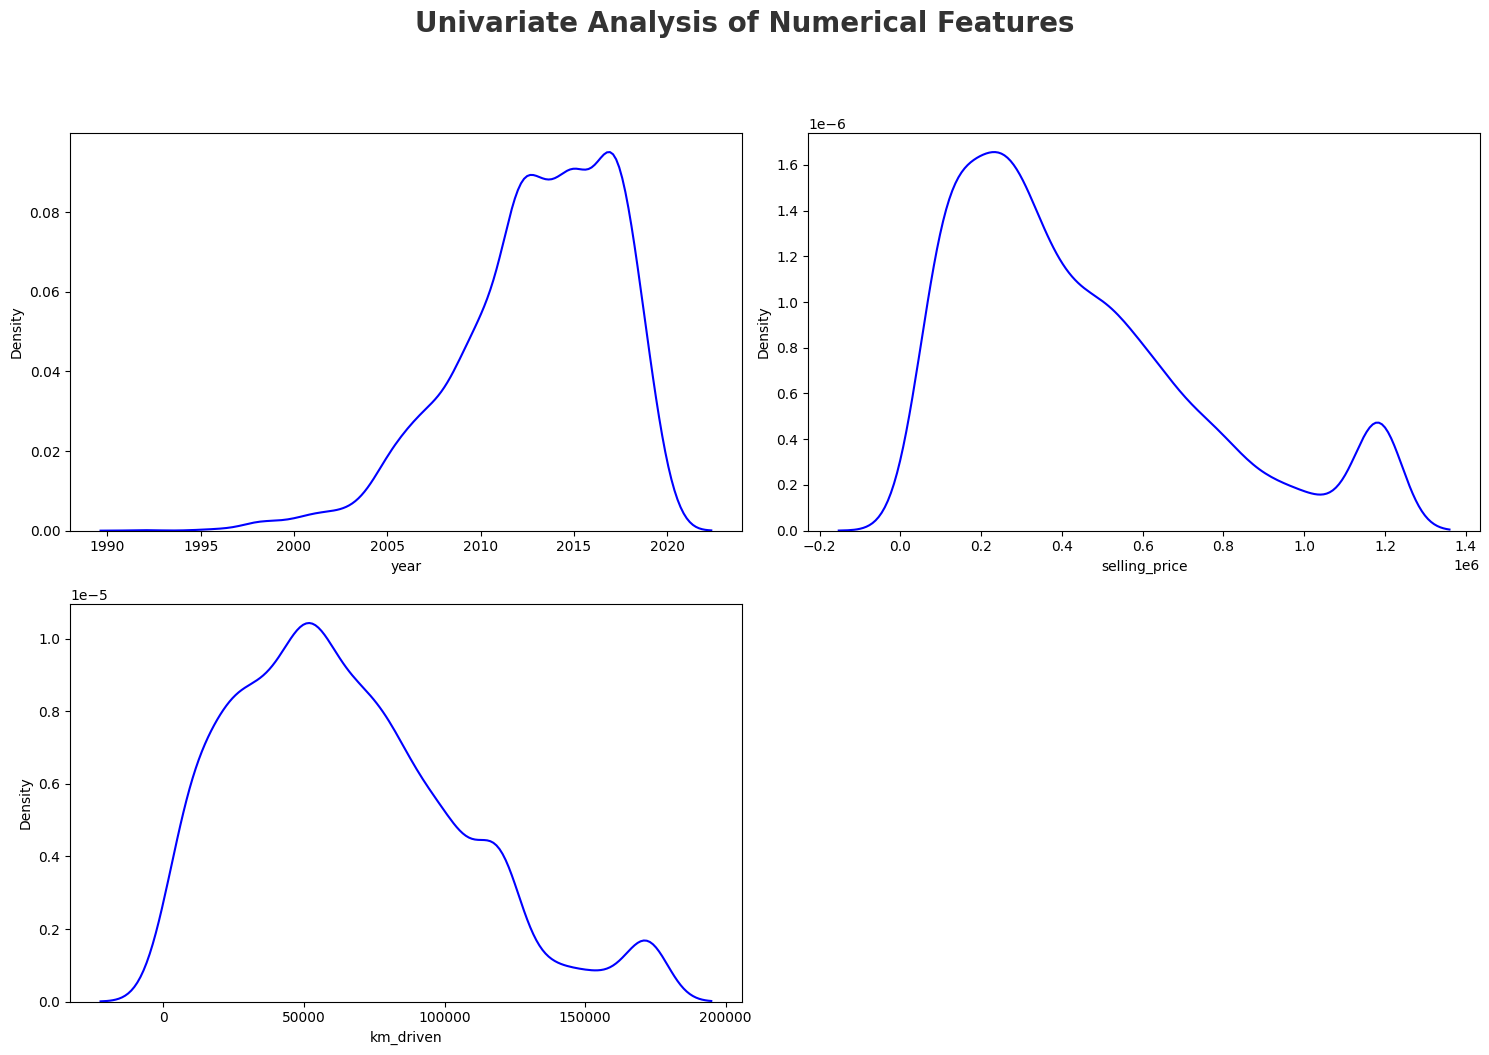

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(15, 10))
plt.suptitle('Univariate Analysis of Numerical Features', fontsize=20, fontweight='bold', alpha=0.8, y=1.05)

for i in range(len(numeric_features)):
    plt.subplot(2, 2, i+1)
    sns.kdeplot(x=df[numeric_features[i]], color='blue')
    plt.xlabel(numeric_features[i])

plt.tight_layout()


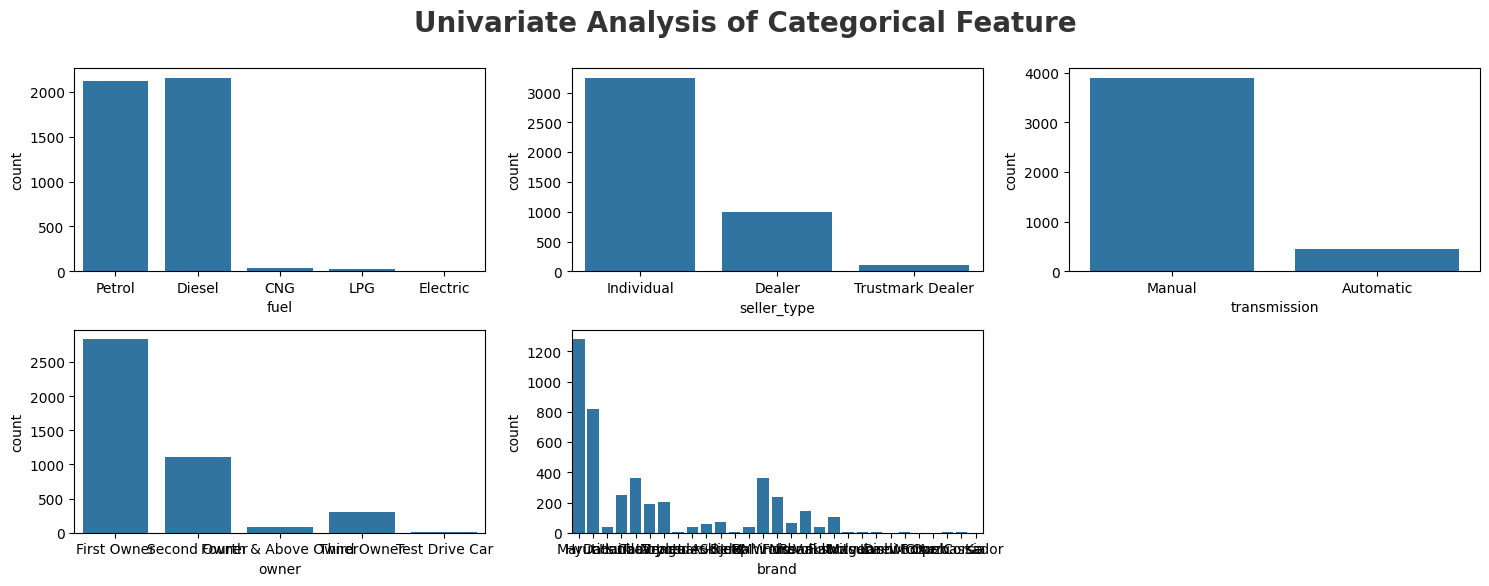

In [43]:
plt.figure(figsize=(15,8))
plt.suptitle("Univariate Analysis of Categorical Feature", fontsize=20, fontweight='bold', alpha=0.8,y=1.)


for i in range(0,len(categorical_feature)):
    plt.subplot(3,3,i+1)
    sns.countplot(x=df[categorical_feature[i]])
    plt.xlabel(categorical_feature[i])
    plt.tight_layout()

In [44]:
# Multi-variate Analysis

discrete_features = [feature for feature in numeric_features if len(df[feature].unique())<=25]

continous_feature = [feature for feature in numeric_features if len(df[feature].unique())>=25]


print("We have {} discreate features: {}".format(len(discrete_features),discrete_features))
print("\nWe have {} continous_features : {}".format(len(continous_feature),continous_feature))

We have 0 discreate features: []

We have 3 continous_features : ['year', 'selling_price', 'km_driven']


In [45]:
# Check for Multicollinearity for Categorical features

In [46]:
from scipy.stats import chi2_contingency
chi2_test = []

for feature in categorical_feature:
    if chi2_contingency(pd.crosstab(df['brand'],df[feature]))[1] < 0.05:
        chi2_test.append("Reject Null Hypothesis")

    else:
        chi2_contingency.append("Fail to Reject Null Hypothesis")

result = pd.DataFrame(data=[categorical_feature,chi2_test]).T
result.columns = ['Column', 'Hypothesis Result']

result

,Column,Hypothesis Result
0,fuel,Reject Null Hypothesis
1,seller_type,Reject Null Hypothesis
2,transmission,Reject Null Hypothesis
3,owner,Reject Null Hypothesis
4,brand,Reject Null Hypothesis


In [47]:
# From the above code we can say that all the categorical columns are important and required to feed the model

In [48]:
df.isnull().sum()

year             0
selling_price    0
km_driven        0
fuel             0
seller_type      0
transmission     0
owner            0
brand            0
dtype: int64

In [49]:
continous_feature = [feature for feature in numeric_features if len(df[feature].unique())>=10]
print('Num of continous features :',continous_feature)

Num of continous features : ['year', 'selling_price', 'km_driven']


C:\Users\samee\AppData\Local\Temp\ipykernel_11216\1253755985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x='brand',y=col, palette=clr1,ax=ax[i,0])
C:\Users\samee\AppData\Local\Temp\ipykernel_11216\1253755985.py:7: UserWarning: 
The palette list has fewer values (2) than needed (29) and will cycle, which may produce an uninterpretable plot.
  sns.boxplot(data=df,x='brand',y=col, palette=clr1,ax=ax[i,0])
C:\Users\samee\AppData\Local\Temp\ipykernel_11216\1253755985.py:9: UserWarning: 
The palette list has fewer values (2) than needed (29) and will cycle, which may produce an uninterpretable plot.
  sns.histplot(data=df,x=col,hue='brand',bins=20,kde=True,
C:\Users\samee\AppData\Local\Temp\ipykernel_11216\1253755985.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. A

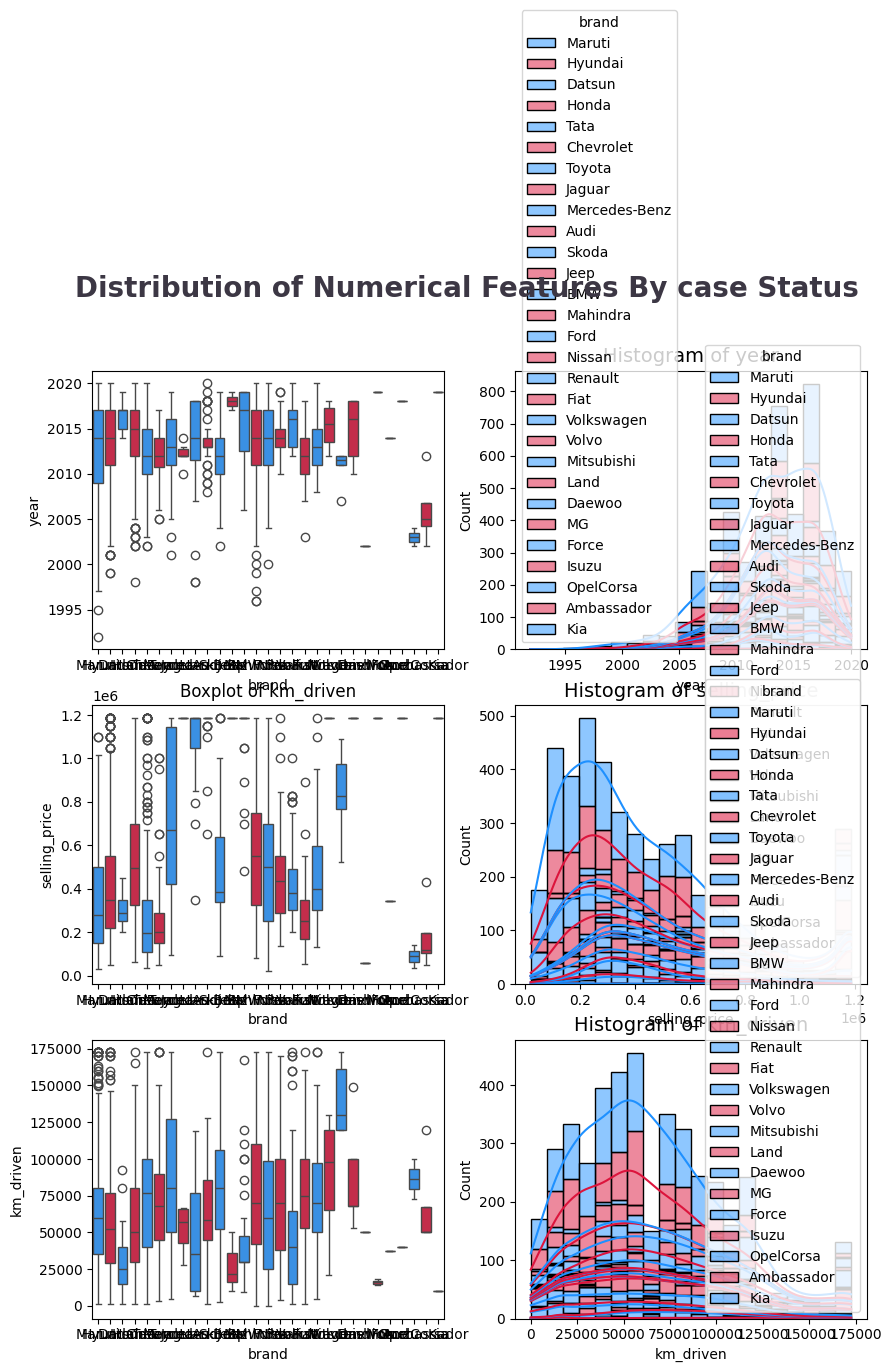

In [50]:
clr1 = ['#1E90FF','#DC143C']
fig, ax = plt.subplots(3,2, figsize=(10,12))
fig.suptitle('Distribution of Numerical Features By case Status',color='#3C3744',
             fontsize=20, fontweight='bold',ha='center')

for i ,col in enumerate(continous_feature):
    sns.boxplot(data=df,x='brand',y=col, palette=clr1,ax=ax[i,0])
    ax[1,0].set_title(f'Boxplot of {col}', fontsize=12)
    sns.histplot(data=df,x=col,hue='brand',bins=20,kde=True,
                 multiple='stack',palette=clr1,ax=ax[i,1])
    
    ax[i,1].set_title(f'Histogram of {col}',fontsize=14)

fig.tight_layout()
fig.subplots_adjust(top=0.90)

In [51]:
# Visualize the target feature

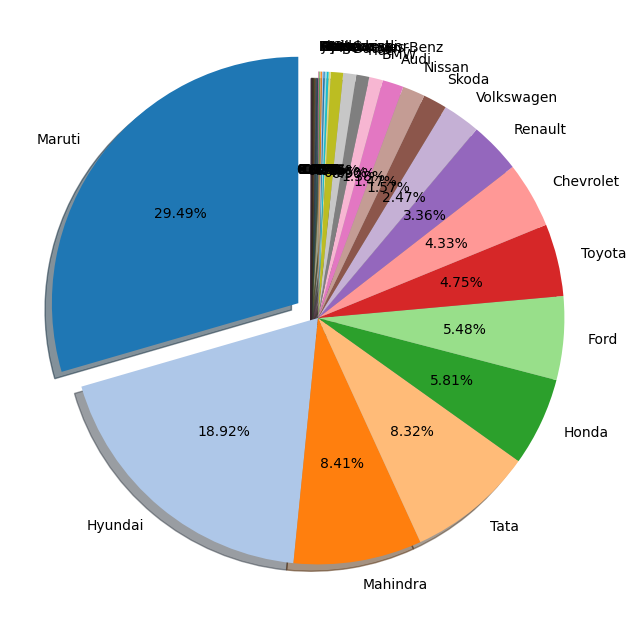

In [41]:
# Calculate percentages
percentage = df['brand'].value_counts(normalize=True) * 100
labels = df['brand'].value_counts().index.tolist()  # Get all unique brand names as labels

# Plot Piechart with the matplotlib library
fig, ax = plt.subplots(figsize=(15, 8))

# Dynamically adjust explode and colors
explode = [0.1 if i == 0 else 0 for i in range(len(labels))]  # Highlight the most frequent brand
colors = plt.cm.tab20.colors  # Use a colormap to handle many colors

# Corrected ax.pie arguments
ax.pie(percentage, labels=labels, startangle=90,
       autopct='%1.2f%%', explode=explode, shadow=True, colors=colors[:len(labels)])

plt.show()


In [56]:
df.groupby("fuel")['brand'].value_counts(normalize=True).to_frame()*100

proportion
fuel     brand                    
CNG      Maruti          75.000000
         Hyundai         20.000000
         Chevrolet        2.500000
         Tata             2.500000
Diesel   Maruti          17.835578
         Mahindra        16.256386
         Hyundai         11.286577
         Tata            10.822109
         Toyota           7.710172
         Ford             7.617278
         Chevrolet        4.505341
         Honda            4.505341
         Renault          3.576405
         Volkswagen       3.437065
         Skoda            2.461681
         Audi             2.415235
         Nissan           2.043660
         BMW              1.764979
         Mercedes-Benz    1.346958
         Fiat             1.254064
         Mitsubishi       0.232234
         Land             0.185787
         Volvo            0.185787
         Ambassador       0.139340
         Jaguar           0.139340
         Jeep             0.092894
         Force            0.046447
         Isuzu            0.046447
         Kia              0.046447
         MG               0.046447
Electric Toyota         100.000000
LPG      Maruti          60.869565
         Hyundai         34.782609
         Chevrolet        4.347826
Petrol   Maruti          40.131889
         Hyundai         26.471974
         Honda            7.300989
         Tata             5.982101
         Chevrolet        4.192181
         Ford             3.485634
         Renault          3.250118
         Toyota           1.837023
         Datsun           1.742817
         Volkswagen       1.554404
         Nissan           0.942063
         Mahindra         0.706547
         Skoda            0.706547
         Fiat             0.471032
         Audi             0.376825
         Mercedes-Benz    0.282619
         Jaguar           0.141309
         OpelCorsa        0.094206
         Ambassador       0.047103
         BMW              0.047103
         Daewoo           0.047103
         Jeep             0.047103
         Land             0.047103
         MG               0.047103
         Mitsubishi       0.047103

In [57]:
df.head()

,year,selling_price,km_driven,fuel,seller_type,transmission,owner,brand
0,2007,60000.0,70000.0,Petrol,Individual,Manual,First Owner,Maruti
1,2007,135000.0,50000.0,Petrol,Individual,Manual,First Owner,Maruti
2,2012,600000.0,100000.0,Diesel,Individual,Manual,First Owner,Hyundai
3,2017,250000.0,46000.0,Petrol,Individual,Manual,First Owner,Datsun
4,2014,450000.0,141000.0,Diesel,Individual,Manual,Second Owner,Honda


In [58]:
df.groupby("seller_type")['brand'].value_counts(normalize=True).to_frame()*100

proportion
seller_type      brand                    
Dealer           Hyundai         20.724346
                 Maruti          19.617706
                 Honda           10.462777
                 Ford            10.362173
                 Mahindra         5.030181
                 Audi             4.728370
                 Renault          4.024145
                 Volkswagen       4.024145
                 Toyota           3.822938
                 Chevrolet        3.621730
                 Tata             3.018109
                 Mercedes-Benz    2.414487
                 Skoda            2.414487
                 BMW              2.012072
                 Nissan           1.408451
                 Datsun           0.905433
                 Fiat             0.402414
                 Jaguar           0.301811
                 Land             0.201207
                 MG               0.201207
                 Volvo            0.201207
                 Mitsubishi       0.100604
Individual       Maruti          31.627620
                 Hyundai         18.434032
                 Tata            10.203453
                 Mahindra         9.679408
                 Toyota           4.716400
                 Chevrolet        4.685573
                 Honda            4.346486
                 Ford             4.130703
                 Renault          3.205919
                 Volkswagen       2.065351
                 Nissan           1.541307
                 Skoda            1.356350
                 Fiat             1.017263
                 Datsun           0.863132
                 BMW              0.585697
                 Audi             0.400740
                 Mercedes-Benz    0.339088
                 Mitsubishi       0.154131
                 Ambassador       0.123305
                 Jaguar           0.092478
                 Jeep             0.092478
                 Land             0.092478
                 OpelCorsa        0.061652
                 Volvo            0.061652
                 Daewoo           0.030826
                 Force            0.030826
                 Isuzu            0.030826
                 Kia              0.030826
Trustmark Dealer Maruti          57.843137
                 Hyundai         16.666667
                 Toyota          14.705882
                 Honda            6.862745
                 Renault          1.960784
                 Ford             0.980392
                 Mahindra         0.980392

In [59]:
# Feature Engineering 